<a href="https://colab.research.google.com/github/RezaFerdiansyah261/SPK/blob/main/Project_SPK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengelompokkan Film Berdasarkan Tahun, Rating, dan Durasi Menggunakan K-Means Clustering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from mpl_toolkits.mplot3d import Axes3D
import io

In [2]:
df = pd.read_csv('/content/sample_data/imdb_top_250.csv')

print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(f"Jumlah film: {len(df)}")
print(f"\nKolom yang tersedia: {list(df.columns)}")
print(f"\nBeberapa baris pertama:")
print(df.head())
print("\n")

INFORMASI DATASET
Jumlah film: 250

Kolom yang tersedia: ['Rank', 'Title', 'Year', 'Rating', 'Runtime']

Beberapa baris pertama:
   Rank                     Title  Year  Rating  Runtime
0     1  The Shawshank Redemption  1994     9.3      142
1     2             The Godfather  1972     9.2      175
2     3           The Dark Knight  2008     9.0      152
3     4     The Godfather Part II  1974     9.0      202
4     5              12 Angry Men  1957     9.0       96




In [3]:
features = ['Year', 'Rating', 'Runtime']
X = df[features]

In [4]:
print("=" * 60)
print("STATISTIK FITUR")
print("=" * 60)
print(X.describe())
print("\n")

STATISTIK FITUR
             Year      Rating     Runtime
count   250.00000  250.000000  250.000000
mean   1985.57200    8.253200  129.108000
std      24.50729    0.255874   31.573468
min    1921.00000    8.000000   45.000000
25%    1966.25000    8.025000  107.000000
50%    1993.00000    8.200000  126.000000
75%    2004.75000    8.400000  144.500000
max    2020.00000    9.300000  312.000000




In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [7]:
cluster_summary = df.groupby('Cluster')[features].mean().reset_index()
print("=" * 60)
print("HASIL CLUSTERING")
print("=" * 60)
print("Rata-rata nilai fitur per cluster:")
print(cluster_summary.to_string(index=False))
print("\n")

HASIL CLUSTERING
Rata-rata nilai fitur per cluster:
 Cluster        Year   Rating    Runtime
       0 1951.245902 8.188525 115.278689
       1 1989.061538 8.521538 161.723077
       2 2000.629032 8.144355 118.814516




In [8]:
print("Jumlah film per cluster:")
print(df['Cluster'].value_counts().sort_index())
print("\n")

Jumlah film per cluster:
Cluster
0     61
1     65
2    124
Name: count, dtype: int64




In [9]:
for cluster_id in sorted(df['Cluster'].unique()):
    print(f"\n--- CLUSTER {cluster_id} ---")
    cluster_films = df[df['Cluster'] == cluster_id].head(5)

    display_cols = ['Title', 'Year', 'Rating', 'Runtime'] if 'Title' in df.columns else features + ['Cluster']
    available_cols = [col for col in display_cols if col in df.columns]

    print("=" * 60)
    print("CONTOH FILM DARI SETIAP CLUSTER")
    print("=" * 60)

    print(cluster_films[available_cols].to_string(index=False))


--- CLUSTER 0 ---
CONTOH FILM DARI SETIAP CLUSTER
                Title  Year  Rating  Runtime
It's a Wonderful Life  1946     8.6      130
           Casablanca  1942     8.5      102
             Harakiri  1962     8.5      133
         Modern Times  1936     8.5       87
          Rear Window  1954     8.5      112

--- CLUSTER 1 ---
CONTOH FILM DARI SETIAP CLUSTER
                   Title  Year  Rating  Runtime
The Shawshank Redemption  1994     9.3      142
           The Godfather  1972     9.2      175
         The Dark Knight  2008     9.0      152
   The Godfather Part II  1974     9.0      202
            12 Angry Men  1957     9.0       96

--- CLUSTER 2 ---
CONTOH FILM DARI SETIAP CLUSTER
                 Title  Year  Rating  Runtime
Léon: The Professional  1994     8.5      110
         The Lion King  1994     8.5       88
    American History X  1998     8.5      119
              Whiplash  2014     8.5      106
    The Usual Suspects  1995     8.5      106


In [10]:
for idx, row in cluster_summary.iterrows():
    cluster_id = int(row['Cluster'])
    count = len(df[df['Cluster'] == cluster_id])

    print("\n" + "=" * 60)
    print("INTERPRETASI CLUSTER")
    print("=" * 60)

    print(f"\nCluster {cluster_id} ({count} film):")
    print(f"  - Tahun rata-rata: {row['Year']:.1f}")
    print(f"  - Rating rata-rata: {row['Rating']:.2f}")
    print(f"  - Durasi rata-rata: {row['Runtime']:.1f} menit")

    if row['Year'] < df['Year'].median():
        era = "Film klasik"
    else:
        era = "Film modern"

    if row['Rating'] > df['Rating'].quantile(0.75):
        quality = "rating sangat tinggi"
    elif row['Rating'] > df['Rating'].median():
        quality = "rating tinggi"
    else:
        quality = "rating standar"

    if row['Runtime'] > df['Runtime'].quantile(0.75):
        length = "durasi panjang"
    elif row['Runtime'] > df['Runtime'].median():
        length = "durasi sedang"
    else:
        length = "durasi pendek"



    print(f"  → Karakteristik: {era}, {quality}, {length}")

print("\n" + "=" * 60)


INTERPRETASI CLUSTER

Cluster 0 (61 film):
  - Tahun rata-rata: 1951.2
  - Rating rata-rata: 8.19
  - Durasi rata-rata: 115.3 menit
  → Karakteristik: Film klasik, rating standar, durasi pendek

INTERPRETASI CLUSTER

Cluster 1 (65 film):
  - Tahun rata-rata: 1989.1
  - Rating rata-rata: 8.52
  - Durasi rata-rata: 161.7 menit
  → Karakteristik: Film klasik, rating sangat tinggi, durasi panjang

INTERPRETASI CLUSTER

Cluster 2 (124 film):
  - Tahun rata-rata: 2000.6
  - Rating rata-rata: 8.14
  - Durasi rata-rata: 118.8 menit
  → Karakteristik: Film modern, rating standar, durasi pendek



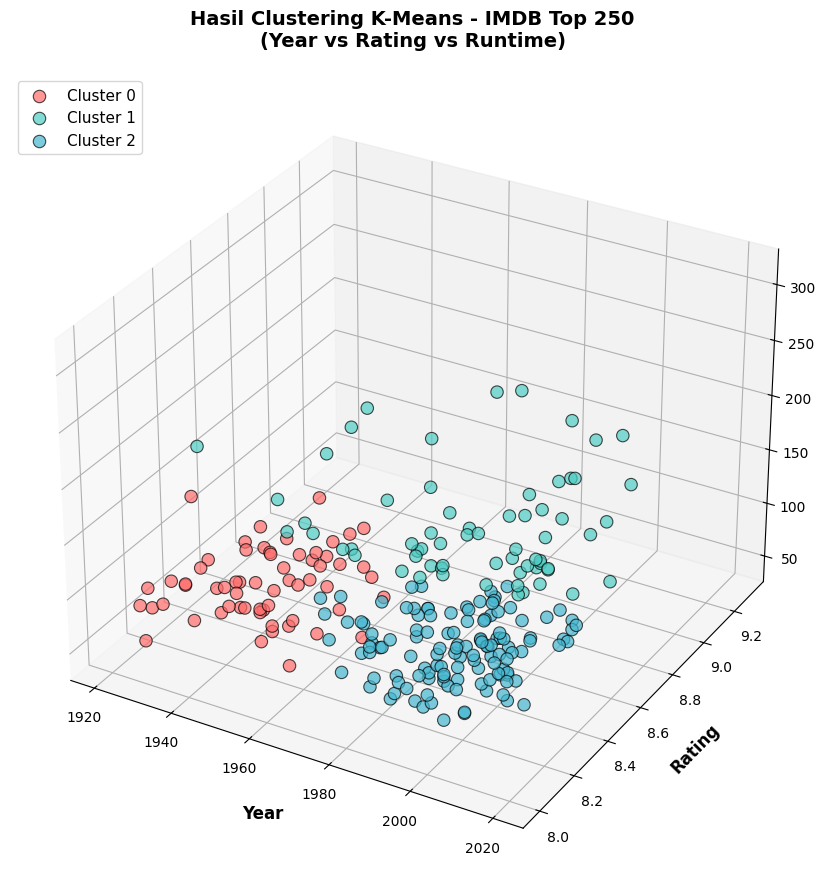

In [11]:
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for i in range(k):
    cluster_data = df[df['Cluster'] == i]
    ax.scatter(cluster_data['Year'],
                cluster_data['Rating'],
                cluster_data['Runtime'],
                c=colors[i],
                label=f'Cluster {i}',
                s=80,
                alpha=0.7,
                edgecolors='black',
                linewidth=0.8)

ax.set_xlabel('Year', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Rating', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('Runtime (minutes)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Hasil Clustering K-Means - IMDB Top 250\n(Year vs Rating vs Runtime)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

In [12]:
print("=" * 70)
print("EVALUASI MODEL CLUSTERING")
print("=" * 70)

# 1. Silhouette Score (range: -1 to 1, semakin tinggi semakin baik)
silhouette = silhouette_score(X_scaled, df['Cluster'])
print(f"\n1. SILHOUETTE SCORE: {silhouette:.4f}")
print(f"   Interpretasi: ", end="")
if silhouette > 0.7:
    print("Excellent - Cluster sangat terpisah dengan baik")
elif silhouette > 0.5:
    print("Good - Cluster cukup terpisah dengan baik")
elif silhouette > 0.3:
    print("Fair - Struktur cluster dapat diterima")
else:
    print("Poor - Cluster kurang terpisah dengan baik")

# 2. Davies-Bouldin Index (semakin rendah semakin baik)
davies_bouldin = davies_bouldin_score(X_scaled, df['Cluster'])
print(f"\n2. DAVIES-BOULDIN INDEX: {davies_bouldin:.4f}")
print(f"   Interpretasi: ", end="")
if davies_bouldin < 0.5:
    print("Excellent - Cluster sangat compact dan terpisah")
elif davies_bouldin < 1.0:
    print("Good - Cluster cukup compact dan terpisah")
else:
    print("Fair - Cluster overlap cukup tinggi")

# 3. Calinski-Harabasz Score (semakin tinggi semakin baik)
calinski = calinski_harabasz_score(X_scaled, df['Cluster'])
print(f"\n3. CALINSKI-HARABASZ SCORE: {calinski:.4f}")
print(f"   Interpretasi: Semakin tinggi menunjukkan cluster lebih padat dan terpisah")

print("\n" + "=" * 70)
print("RINGKASAN HASIL CLUSTERING")
print("=" * 70)
cluster_summary = df.groupby('Cluster')[features].mean()
print("\nRata-rata nilai fitur per cluster:")
print(cluster_summary.round(2))
print("\nJumlah film per cluster:")
print(df['Cluster'].value_counts().sort_index())

print("\n" + "=" * 70)
print("KESIMPULAN EVALUASI")
print("=" * 70)
print(f"Model K-Means dengan k={k} menghasilkan clustering dengan:")
print(f"- Silhouette Score: {silhouette:.4f} (kualitas separasi cluster)")
print(f"- Davies-Bouldin Index: {davies_bouldin:.4f} (kualitas kompaksi cluster)")
print(f"- Calinski-Harabasz Score: {calinski:.4f} (rasio variance antar/dalam cluster)")
print("=" * 70)

EVALUASI MODEL CLUSTERING

1. SILHOUETTE SCORE: 0.3281
   Interpretasi: Fair - Struktur cluster dapat diterima

2. DAVIES-BOULDIN INDEX: 1.1257
   Interpretasi: Fair - Cluster overlap cukup tinggi

3. CALINSKI-HARABASZ SCORE: 114.7972
   Interpretasi: Semakin tinggi menunjukkan cluster lebih padat dan terpisah

RINGKASAN HASIL CLUSTERING

Rata-rata nilai fitur per cluster:
            Year  Rating  Runtime
Cluster                          
0        1951.25    8.19   115.28
1        1989.06    8.52   161.72
2        2000.63    8.14   118.81

Jumlah film per cluster:
Cluster
0     61
1     65
2    124
Name: count, dtype: int64

KESIMPULAN EVALUASI
Model K-Means dengan k=3 menghasilkan clustering dengan:
- Silhouette Score: 0.3281 (kualitas separasi cluster)
- Davies-Bouldin Index: 1.1257 (kualitas kompaksi cluster)
- Calinski-Harabasz Score: 114.7972 (rasio variance antar/dalam cluster)
